STEP 1 - mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Import libraries

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

STEP 3 — Upload your ZIP dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Audio_Speech_Actors_01-24_16k.zip to Audio_Speech_Actors_01-24_16k (1).zip


STEP 4 — Extract the ZIP

In [ ]:
zip_path = "/content/Audio_Speech_Actors_01-24_16k.zip"

extract_path = "/content/audio_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


STEP 5 — Check the dataset

In [ ]:
for root, dirs, files in os.walk(extract_path):
    wav_files = [f for f in files if f.endswith(".wav")]

    if wav_files:
        print(root, ":", len(wav_files), "audio files")

/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_20 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_19 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_03 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_05 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_24 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_22 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_13 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_21 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_11 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_14 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_23 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k/Actor_07 : 60 audio files
/content/audio_dataset/Audio_Speech_Actors_01-24_16k

STEP 6 — Create the emotion mapping

In [ ]:
emotion_map = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

STEP 7 — Create function to read emotion from filename

In [ ]:
def get_emotion(filename):

    parts = filename.replace(".wav", "").split("-")

    emotion_code = int(parts[2])

    return emotion_map[emotion_code

test it

In [ ]:
print(get_emotion("03-01-05-01-02-01-01.wav"))

angry


another test

In [ ]:
print(get_emotion("03-01-03-01-01-01-01.wav"))

happy


STEP 8 — Create dataset DataFrame

In [ ]:
audio_paths = []
emotions = []
actors = []

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.endswith(".wav"):

            path = os.path.join(root, file)

            emotion = get_emotion(file)

            actor = os.path.basename(root)

            audio_paths.append(path)
            emotions.append(emotion)
            actors.append(actor)

Now Create DataFrame

In [ ]:
data = pd.DataFrame({
    "Path": audio_paths,
    "Emotion": emotions,
    "Actor": actors
})

Check

In [ ]:
print(data.head())

                                                Path    Emotion     Actor
0  /content/audio_dataset/Audio_Speech_Actors_01-...      angry  Actor_20
1  /content/audio_dataset/Audio_Speech_Actors_01-...       calm  Actor_20
2  /content/audio_dataset/Audio_Speech_Actors_01-...  surprised  Actor_20
3  /content/audio_dataset/Audio_Speech_Actors_01-...    fearful  Actor_20
4  /content/audio_dataset/Audio_Speech_Actors_01-...      happy  Actor_20


and

In [ ]:
print("Total files:", len(data))

Total files: 1440


STEP 9 — Check emotion distribution

In [ ]:
print(data["Emotion"].value_counts())

Emotion
angry        192
calm         192
surprised    192
fearful      192
happy        192
sad          192
disgust      192
neutral       96
Name: count, dtype: int64


STEP 10 — Display emotion distribution

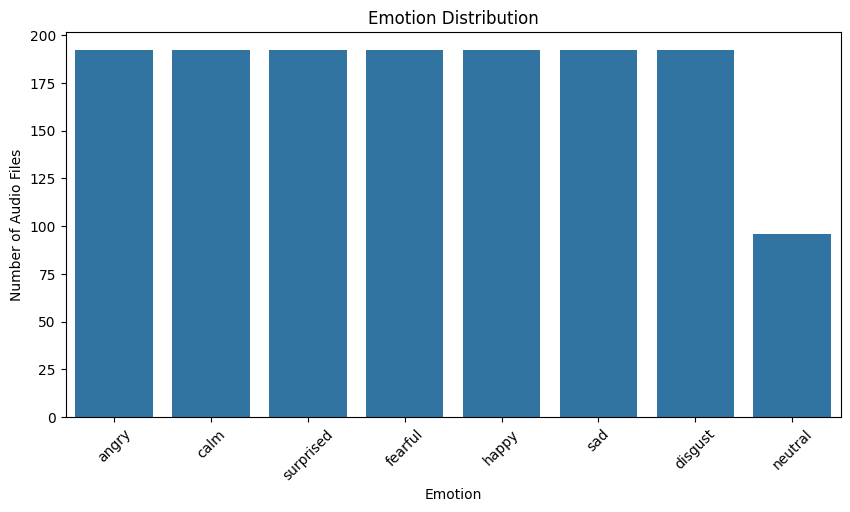

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="Emotion"
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)

plt.show()

STEP 11 — Play one audio file

In [ ]:
from IPython.display import Audio

sample_path = data.iloc[0]["Path"]

Audio(sample_path)

STEP 12 — Display waveform

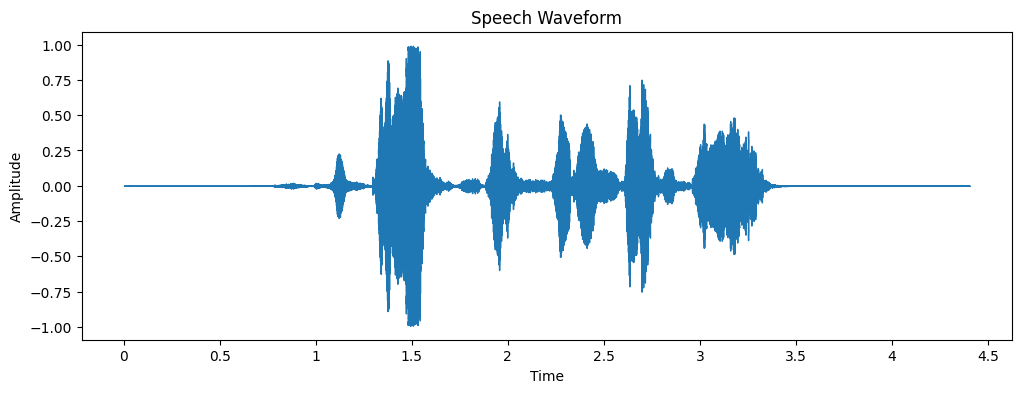

In [ ]:
audio, sr = librosa.load(sample_path, sr=16000)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

STEP 13 — Extract MFCC features

In [ ]:
def extract_mfcc(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40,
        n_fft=512,
        hop_length=256
    )

    # Make all samples the same size
    max_length = 250

    if mfcc.shape[1] < max_length:

        pad_width = max_length - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )

    else:

        mfcc = mfcc[:, :max_length]

    return mfcc

STEP 14 — Test MFCC extraction

In [ ]:
mfcc = extract_mfcc(sample_path)

print("MFCC shape:", mfcc.shape)

MFCC shape: (40, 250)


STEP 15 — Display MFCC

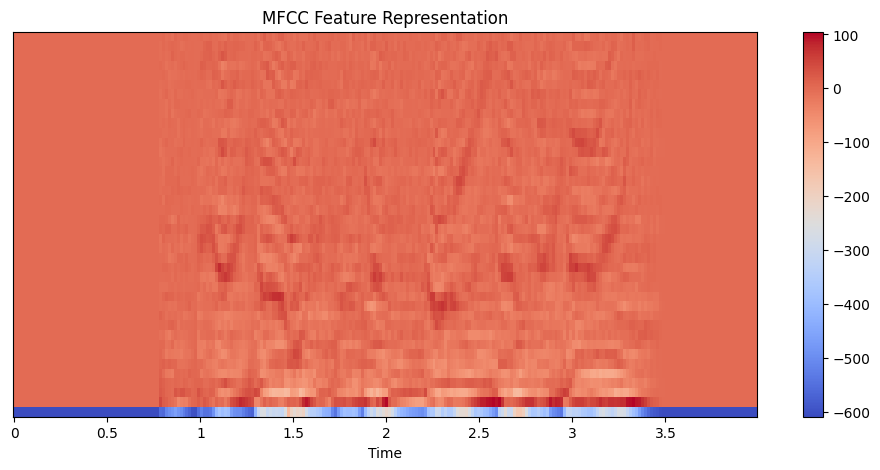

In [ ]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    sr=16000,
    hop_length=256,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC Feature Representation")

plt.show()

STEP 16 — Extract MFCC from all 1,440 files

In [ ]:
X = []
y = []
actors = []

for index, row in data.iterrows():

    try:

        mfcc = extract_mfcc(row["Path"])

        X.append(mfcc)
        y.append(row["Emotion"])
        actors.append(row["Actor"])

    except Exception as e:

        print("Error:", row["Path"])

Convert to NumPy

In [ ]:
X = np.array(X)
y = np.array(y)
actors = np.array(actors)

Check

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 40, 250)
y shape: (1440,)


STEP 17 — Add CNN channel dimension

In [ ]:
X = X[..., np.newaxis]

print(X.shape)

(1440, 40, 250, 1)


STEP 18 — Encode emotion labels

In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


STEP 21 — Important: split actors properly

In [ ]:
unique_actors = sorted(np.unique(actors))

print(unique_actors)

[np.str_('Actor_01'), np.str_('Actor_02'), np.str_('Actor_03'), np.str_('Actor_04'), np.str_('Actor_05'), np.str_('Actor_06'), np.str_('Actor_07'), np.str_('Actor_08'), np.str_('Actor_09'), np.str_('Actor_10'), np.str_('Actor_11'), np.str_('Actor_12'), np.str_('Actor_13'), np.str_('Actor_14'), np.str_('Actor_15'), np.str_('Actor_16'), np.str_('Actor_17'), np.str_('Actor_18'), np.str_('Actor_19'), np.str_('Actor_20'), np.str_('Actor_21'), np.str_('Actor_22'), np.str_('Actor_23'), np.str_('Actor_24')]


Create the split:

In [ ]:
train_actors = unique_actors[:19]
test_actors = unique_actors[19:]

Check

In [ ]:
print("Training actors:", train_actors)
print("Testing actors:", test_actors)

Training actors: [np.str_('Actor_01'), np.str_('Actor_02'), np.str_('Actor_03'), np.str_('Actor_04'), np.str_('Actor_05'), np.str_('Actor_06'), np.str_('Actor_07'), np.str_('Actor_08'), np.str_('Actor_09'), np.str_('Actor_10'), np.str_('Actor_11'), np.str_('Actor_12'), np.str_('Actor_13'), np.str_('Actor_14'), np.str_('Actor_15'), np.str_('Actor_16'), np.str_('Actor_17'), np.str_('Actor_18'), np.str_('Actor_19')]
Testing actors: [np.str_('Actor_20'), np.str_('Actor_21'), np.str_('Actor_22'), np.str_('Actor_23'), np.str_('Actor_24')]


STEP 22 — Create training and testing datasets

In [ ]:
train_indices = [
    i for i, actor in enumerate(actors)
    if actor in train_actors
]

test_indices = [
    i for i, actor in enumerate(actors)
    if actor in test_actors
]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y_encoded[train_indices]
y_test = y_encoded[test_indices]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1140, 40, 250, 1)
Testing : (300, 40, 250, 1)


STEP 23 — Convert labels to categorical

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(
    y_train,
    num_classes=8
)

y_test_cat = to_categorical(
    y_test,
    num_classes=8
)

STEP 24 — Build CNN model

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(40,250,1)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        8,
        activation="softmax"
    )
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 25 — Compile CNN

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

STEP 26 — View model

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 248, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 124, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 122, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 61, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 59, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 29, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11136)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,425,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,519,240 (5.80 MB)

 Trainable params: 1,519,240 (5.80 MB)

 Non-trainable params: 0 (0.00 B)

STEP 27 — Train the model

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 630ms/step - accuracy: 0.1952 - loss: 4.6882 - val_accuracy: 0.2061 - val_loss: 1.9798
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 599ms/step - accuracy: 0.2664 - loss: 1.8780 - val_accuracy: 0.3246 - val_loss: 1.8377
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 601ms/step - accuracy: 0.3048 - loss: 1.8082 - val_accuracy: 0.3246 - val_loss: 1.8404
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 601ms/step - accuracy: 0.3366 - loss: 1.7738 - val_accuracy: 0.3070 - val_loss: 1.7692
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 655ms/step - accuracy: 0.3882 - loss: 1.6528 - val_accuracy: 0.3114 - val_loss: 1.7417
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 649ms/step - accuracy: 0.4134 - loss: 1.5613 - val_accuracy: 0.3114 - val_loss: 1.7740
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 620ms/step - accuracy: 0.4419 - loss: 1.4827 - val_accuracy: 0.3728 - val_loss: 1.7185
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 613ms/step - accuracy: 0.4803 - loss: 1.3504 - val_accu

STEP 28 — Plot training accuracy

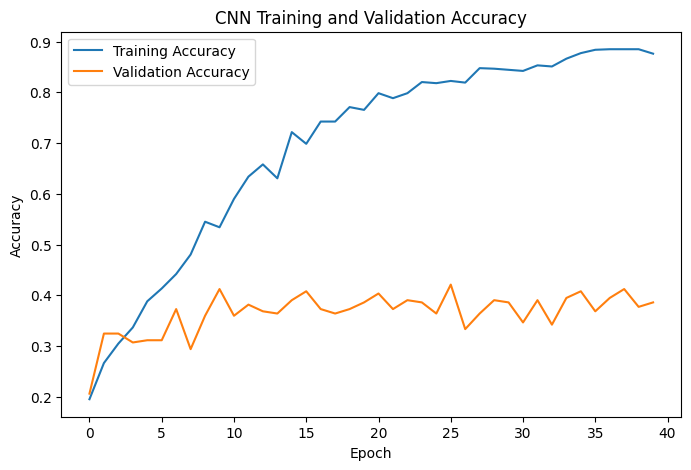

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

STEP 29 — Plot loss

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

STEP 30 — Evaluate the model

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.4300 - loss: 3.7019
Test Loss: 3.7018513679504395
Test Accuracy: 0.4300000071525574


STEP 31 — Make predictions

In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step


STEP 32 — Classification report

In [ ]:
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.53      0.40      0.46        40
        calm       0.58      0.45      0.51        40
     disgust       0.49      0.50      0.49        40
     fearful       0.44      0.40      0.42        40
       happy       0.27      0.20      0.23        40
     neutral       0.43      0.15      0.22        20
         sad       0.24      0.40      0.30        40
   surprised       0.55      0.80      0.65        40

    accuracy                           0.43       300
   macro avg       0.44      0.41      0.41       300
weighted avg       0.44      0.43      0.42       300



STEP 33 — Confusion matrix

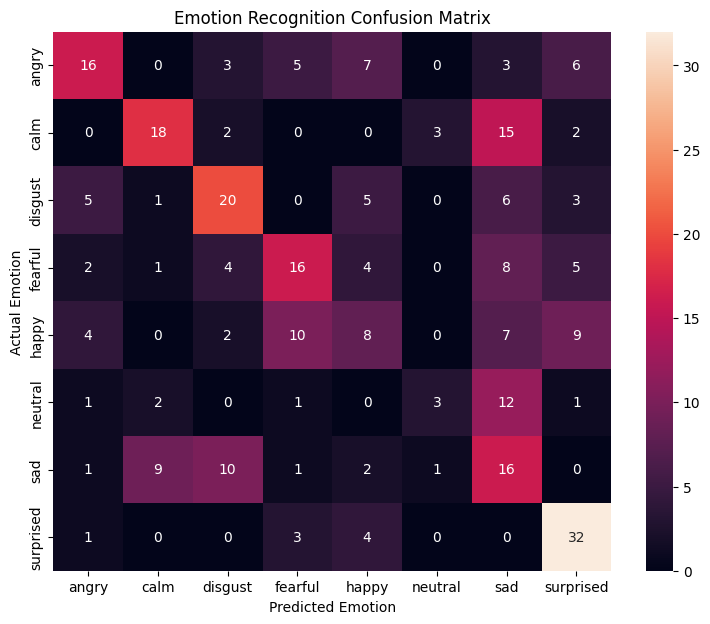

In [ ]:
cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Emotion Recognition Confusion Matrix")

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.show()

STEP 34 — Create prediction function

In [ ]:
def predict_emotion(file_path):

    mfcc = extract_mfcc(file_path)

    mfcc = mfcc[np.newaxis, ...]
    mfcc = mfcc[..., np.newaxis]

    prediction = model.predict(mfcc)

    predicted_index = np.argmax(prediction)

    emotion = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = np.max(prediction) * 100

    print("Predicted Emotion:", emotion)
    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )

STEP 35 — Save the model

In [ ]:
model.save(
    "emotion_recognition_cnn.keras"
)

save the label encoder

In [ ]:
import pickle

with open(
    "emotion_label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(
        label_encoder,
        f
    )